# Chapter 8 (Economic Modeling) — DICE Calibration Building Blocks

DICE (Dynamic Integrated Climate-Economy) is Nordhaus's canonical
integrated-assessment model, coupling a Cobb-Douglas economy to a physical
climate module through an endogenous carbon price. This notebook builds up
DICE's *exogenous input blocks* one at a time — population, total factor
productivity (TFP), capital accumulation, climate damage functions, and
abatement costs — calibrated against real historical data (UN World
Population Prospects 2022, Penn World Table 10.0, IMF Investment and
Capital Stock Dataset) and the model's own published base-year (2019/2020)
figures. None of this involves solving DICE's actual optimal-control
problem (choosing the abatement/savings paths that maximize discounted
welfare) — that is the subject of the next notebook, which displays
Nordhaus's own precomputed scenario runs rather than re-solving that
optimization, since the data and solver needed to re-derive them from
scratch aren't available here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.stats import gamma as gamma_dist
from scipy.io.matlab import MatReadWarning

# The TFP dataset stores its Country/Code_Iso fields as text-class arrays that
# scipy.io cannot parse -- loadmat emits a benign "Duplicate variable name"
# MatReadWarning while loading them, even though the numeric fields (TFP,
# WTFP, Years) we actually use load cleanly. Suppressed here since it's a
# known loader limitation, disclosed below.
warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda v: f"{v: .4f}")

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#ff33ff"
color_black = "#000000"
color_darkblue = "#00008b"
color_teal = "#17becf"
color_yellow = "#ffdd00"
color_skyblue = "#87ceeb"
color_darkorange = "#ff8c00"
color_maroon = "#800000"
color_navy = "#000080"
color_coral = "#ff7f50"


def lag1(x):
    '''Shift the series by one period, NaN-filling the first row.'''
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan)
    out[1:] = x[:-1]
    return out


## Question 1 — Population: logistic-decay growth-rate scenarios

DICE's population module assumes the population growth rate itself decays
geometrically toward zero at rate $\delta_L$: $g_L(t) = g_L(t-1)/(1+\delta_L)$,
$L(t) = (1+g_L(t))L(t-1)$. The base-case $\delta_L$ is calibrated so that
the growth rate implied by 2020's actual population reaches the UN's 2050
consensus growth rate ($2.045\%\to 0\%$-ish trajectory) after 30 years.


g_L0 = 1.036%   delta_L (base calibration) = 2.292%

L(2100) under the 3 scenarios: 11.4, 12.6, 10.5 bn


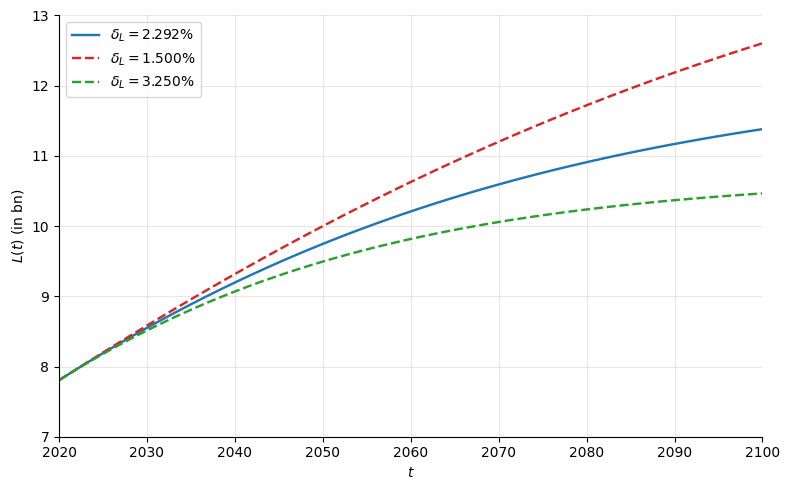

In [2]:
t0 = 2020
L0 = 7.804974
g_L0 = 7.804974 / 7.724928 - 1
delta_L_base = (0.02045 / g_L0) ** (1 / 30) - 1

print(f"g_L0 = {100*g_L0:.3f}%   delta_L (base calibration) = {100*delta_L_base:.3f}%")

def simulate_population(delta_L, nT=81, L0=L0, g_L0=g_L0):
    L = np.zeros(nT)
    g_L = np.zeros(nT)
    L[0] = L0
    g_L[0] = g_L0
    for t in range(1, nT):
        g_L[t] = g_L[t - 1] / (1 + delta_L)
        L[t] = (1 + g_L[t]) * L[t - 1]
    return L

L1 = simulate_population(delta_L_base)
L2 = simulate_population(0.015)
L3 = simulate_population(0.0325)

print(f"\nL(2100) under the 3 scenarios: {L1[-1]:.1f}, {L2[-1]:.1f}, {L3[-1]:.1f} bn")

t = np.arange(t0, t0 + 81)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, L1, "-", color=color_blue, lw=1.75, label=r"$\delta_L=2.292\%$")
ax.plot(t, L2, "--", color=color_red, lw=1.75, label=r"$\delta_L=1.500\%$")
ax.plot(t, L3, "--", color=color_green, lw=1.75, label=r"$\delta_L=3.250\%$")
ax.set_xlabel("$t$")
ax.set_ylabel("$L(t)$ (in bn)")
ax.set_xlim(2020, 2100)
ax.set_ylim(7, 13)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Question 2 — UN World Population Prospects 2022: observed, median, and probabilistic bands


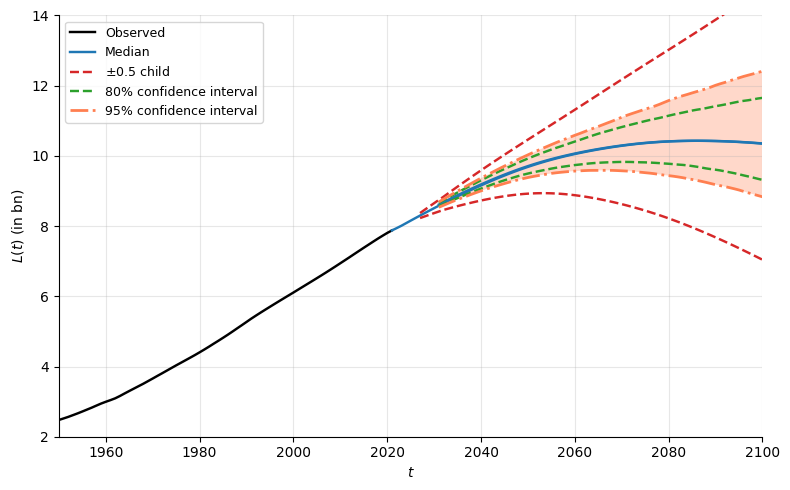

In [3]:
wpp = sio.loadmat(f"{DATA_DIR}/chap8_WPP_2022.mat")
wpp_estimate_year = wpp["wpp_estimate_year"].ravel().astype(float)
wpp_estimate_population = wpp["wpp_estimate_population"].ravel()
wpp_estimate_growth = wpp["wpp_estimate_growth"].ravel()
wpp_forecast_year = wpp["wpp_forecast_year"].ravel().astype(float)
wpp_forecast_population = wpp["wpp_forecast_population"].astype(float)
wpp_probabilistic_year = wpp["wpp_probabilistic_year"].ravel().astype(float)
wpp_probabilistic_population = wpp["wpp_probabilistic_population"].astype(float)

# prepend the last observed point so the forecast/probabilistic fans connect visually
fy = np.concatenate([[wpp_estimate_year[-1]], wpp_forecast_year])
fp = np.vstack([np.full(3, wpp_estimate_population[-1]), wpp_forecast_population])
fp[1:6, 1:3] = np.nan  # blank the +/- 0.5-child bands for the first few forecast points

py = wpp_probabilistic_year[9:]
pp = wpp_probabilistic_population[9:]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wpp_estimate_year, wpp_estimate_population, "-", color=color_black, lw=1.75, label="Observed")
ax.plot(fy, fp[:, 0], "-", color=color_blue, lw=1.75, label="Median")
ax.plot(fy, fp[:, 2], "--", color=color_red, lw=1.75, label=r"$\pm 0.5$ child")
ax.plot(fy, fp[:, 1], "--", color=color_red, lw=1.75)
ax.plot(py, pp[:, 2], "-", color=color_blue, lw=1.75)
ax.plot(py, pp[:, 1], "--", color=color_green, lw=1.75, label="80% confidence interval")
ax.plot(py, pp[:, 3], "--", color=color_green, lw=1.75)
ax.plot(py, pp[:, 0], "-.", color=color_coral, lw=2.0, label="95% confidence interval")
ax.plot(py, pp[:, 4], "-.", color=color_coral, lw=2.0)

x_fill = py[2:]
y1_fill, y2_fill = pp[2:, 0], pp[2:, 4]
ax.fill(np.concatenate([x_fill, x_fill[::-1]]), np.concatenate([y1_fill, y2_fill[::-1]]),
        color=color_coral, alpha=0.30, edgecolor="none")

ax.set_xlabel("$t$")
ax.set_ylabel("$L(t)$ (in bn)")
ax.set_xlim(1950, 2100)
ax.set_ylim(2, 14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Question 3 — Calibrating the growth-rate decay rate $\delta_L$ from history

Two independent calibrations of the same geometric-decay assumption against
1970-2025 observed population growth: an AR(1) regression of $g_L(t)$ on
$g_L(t-1)$ (giving $\delta_L = 1/\hat\phi - 1$), and an OLS log-linear time
trend $\log g_L(t) = \beta_0 + \beta_1 t$ (giving $\delta_L = e^{-\hat\beta_1}-1$).


AR(1): phi = 0.985   delta_L = 1.529%
OLS log-linear: beta = [ 0.724129   -0.01359823]   delta_L = 1.369%


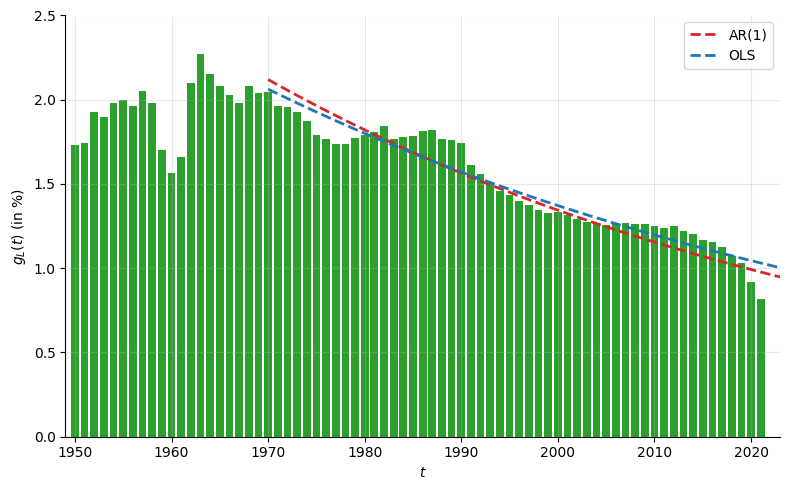

In [4]:
cnd1 = wpp_estimate_year >= 1971
y = 100 * wpp_estimate_growth[cnd1]
cnd0 = wpp_estimate_year >= 1970
x = (100 * wpp_estimate_growth[cnd0])[:-1]

phi_ar1 = (x @ y) / (x @ x)
delta_ar1 = 1 / phi_ar1 - 1
print(f"AR(1): phi = {phi_ar1:.3f}   delta_L = {100*delta_ar1:.3f}%")

cnd = wpp_estimate_year >= 1970
x_t = wpp_estimate_year[cnd] - 1970
y_log = np.log(100 * wpp_estimate_growth[cnd])
X = np.column_stack([np.ones_like(x_t), x_t])
beta_ols, *_ = np.linalg.lstsq(X, y_log, rcond=None)
delta_ols = np.exp(-beta_ols[1]) - 1
print(f"OLS log-linear: beta = {beta_ols}   delta_L = {100*delta_ols:.3f}%")

t = np.arange(1970, 2026)
g1 = 2.12 * (1 / (1 + delta_ar1)) ** (t - 1970)
g0_ols = np.exp(beta_ols[0])
g2 = g0_ols * (1 / (1 + delta_ols)) ** (t - 1970)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(wpp_estimate_year, 100 * wpp_estimate_growth, color=color_green, edgecolor="none")
ax.plot(t, g1, "--", color=color_red, lw=2.0, label="AR(1)")
ax.plot(t, g2, "--", color=color_blue, lw=2.0, label="OLS")
ax.set_xlabel("$t$")
ax.set_ylabel("$g_L(t)$ (in %)")
ax.set_xlim(1949, 2023)
ax.set_ylim(0, 2.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Question 4 — Total Factor Productivity, 12 countries (Penn World Table 10.0)

TFP indices (1960=100) for 12 major economies, sorted by 2020 level. The
data file's `Country`/`Code_Iso` text fields serialize in a form
`scipy.io.loadmat` cannot parse — the numeric `TFP`/`WTFP`/`Years` arrays
load cleanly, and the 12-country list plus its exact column order is
known from the dataset's documentation, so the ISO3 codes are supplied
directly here (standard, unambiguous 3-letter country codes, not derived
data) rather than treated as a gap.


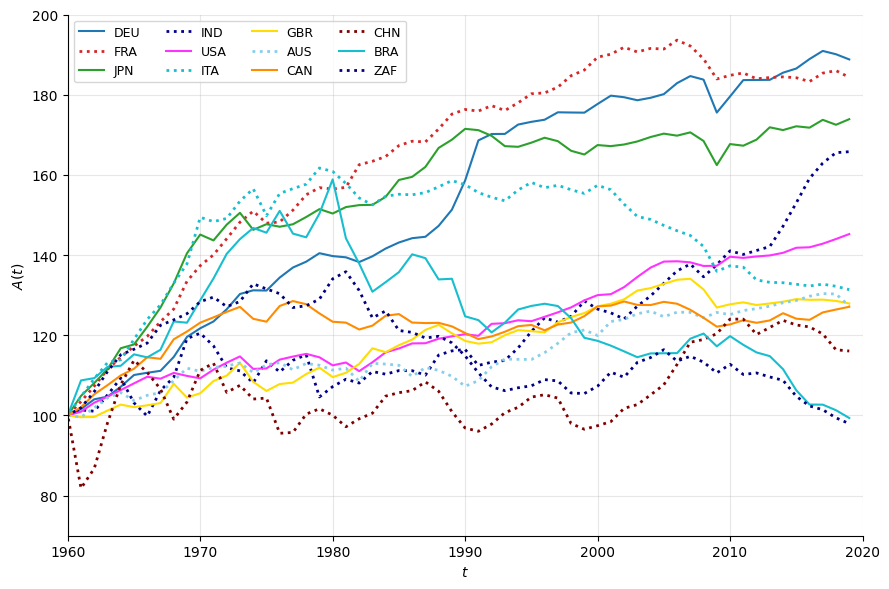

In [5]:
tfp_mat = sio.loadmat(f"{DATA_DIR}/chap8_TFP_PWT_2021.mat")
TFP = tfp_mat["TFP"]
Years_tfp = tfp_mat["Years"].ravel().astype(int)
Country = np.array(["Australia", "Brazil", "Canada", "China", "France", "Germany",
                     "India", "Italy", "Japan", "South Africa", "United Kingdom", "United States"])
Code_Iso = np.array(["AUS", "BRA", "CAN", "CHN", "FRA", "DEU", "IND", "ITA", "JPN", "ZAF", "GBR", "USA"])

indx0 = np.where(Years_tfp == 1960)[0][0]
TFP_norm = TFP / TFP[indx0, :]
order = np.argsort(TFP_norm[-1, :])[::-1]
TFP_norm = TFP_norm[:, order]
Code_Iso_sorted = Code_Iso[order]

colours = [color_blue, color_red, color_green, color_darkblue, color_violet, color_teal,
           color_yellow, color_skyblue, color_darkorange, color_maroon, color_teal, color_navy]
styles = ["-", ":", "-", ":", "-", ":", "-", ":", "-", ":", "-", ":"]

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(len(Code_Iso_sorted)):
    lw = 2.0 if (i + 1) % 2 == 0 else 1.5
    ax.plot(Years_tfp, 100 * TFP_norm[:, i], styles[i], color=colours[i], lw=lw, label=Code_Iso_sorted[i])
ax.set_xlabel("$t$")
ax.set_ylabel("$A(t)$")
ax.set_xlim(1960, 2020)
ax.set_ylim(70, 200)
ax.grid(True, alpha=0.3)
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


## Question 5 — TFP growth-rate decade averages

Mean year-over-year TFP growth by decade, 1960-2020, for the same 12
countries (unsorted, original country order).


In [6]:
g_A = TFP[1:] / TFP[:-1] - 1  # year-over-year TFP growth rate, valid (non-first) rows only
Years_gA = Years_tfp[1:]

brk = [1960, 1970, 1980, 1990, 2000, 2010, 2020]
n_periods = len(brk) - 1
results_5 = np.zeros((len(Country), n_periods))
for i in range(n_periods):
    cnd = (Years_gA >= brk[i]) & (Years_gA < brk[i + 1])
    results_5[:, i] = g_A[cnd, :].mean(axis=0)

df_5 = pd.DataFrame(100 * results_5, index=Code_Iso,
                     columns=[f"{brk[i]}s" for i in range(n_periods)])
print("Question 5 -- mean TFP growth rate by decade (%)")
display(df_5.round(2))


Question 5 -- mean TFP growth rate by decade (%)


,1960s,1970s,1980s,1990s,2000s,2010s
AUS,1.0200,0.0700,-0.2300,1.0200,0.3600,0.1300
BRA,2.3900,2.0500,-1.0400,-1.1200,-0.1700,-1.6300
CAN,2.1800,0.3800,-0.2500,0.2100,-0.2100,0.4000
CHN,-0.0300,-0.0600,-0.0400,-0.4100,2.2400,-0.3500
FRA,3.5900,1.6300,1.1200,0.6100,-0.1100,0.0200
DEU,2.3300,1.6300,0.7500,1.5200,0.0100,0.7400
IND,2.3700,-1.2200,1.0600,1.0400,0.7000,1.8900
ITA,3.7100,1.6600,-0.1900,-0.2000,-1.3200,-0.3400
JPN,4.0500,0.7700,1.0900,-0.2200,-0.1500,0.6900
ZAF,2.3700,0.3000,-0.8400,-1.1100,0.5000,-1.2000


## Question 6 — TFP growth-rate decay under 3 asymptotic-doubling assumptions

Same geometric-decay structure as population, applied to TFP growth: the
decay rate $\delta_A$ is calibrated so the initial growth rate compounds to
a $d$-fold increase in $A(t)$ after $n=50$ years, for $d\in\{2,3,5\}$.


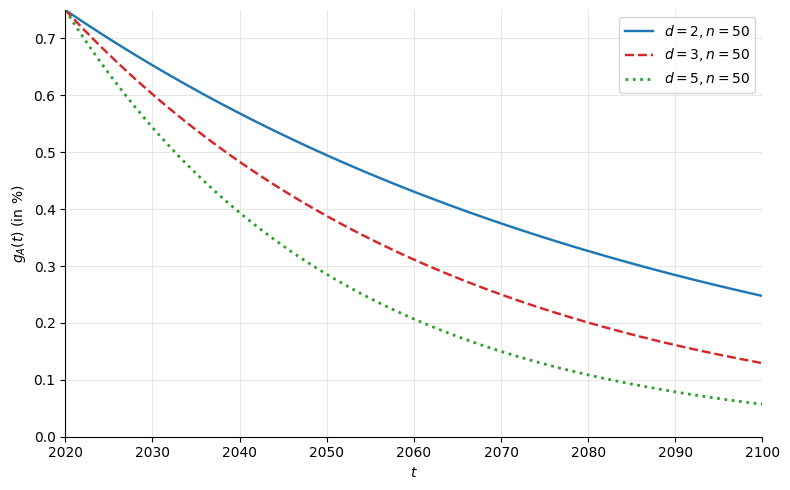

In [7]:
t = np.arange(2020, 2101)
t0 = 2020
g_A0 = 0.75 / 100
n_years = 50

def g_A_path(d, n=n_years):
    delta_A = d ** (1 / n) - 1
    return g_A0 * (1 / (1 + delta_A)) ** (t - t0)

g_A1, g_A2, g_A3 = g_A_path(2), g_A_path(3), g_A_path(5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, 100 * g_A1, "-", color=color_blue, lw=1.75, label="$d=2, n=50$")
ax.plot(t, 100 * g_A2, "--", color=color_red, lw=1.75, label="$d=3, n=50$")
ax.plot(t, 100 * g_A3, ":", color=color_green, lw=2.0, label="$d=5, n=50$")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$g_A(t)$ (in %)")
ax.set_xlim(2020, 2100)
ax.set_ylim(0, 0.75)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Question 7 — Global investment, capital, output, and depreciation (IMF ICSD 2021)

Global aggregate investment $I(t)$, capital stock $K(t)$, output $Y(t)$
(each summed across the IMF dataset's private/public/PPP components), and
the implied capital depreciation rate $\delta_K(t) = 1-(K_t-I_t)/K_{t-1}$
(3-year moving average).


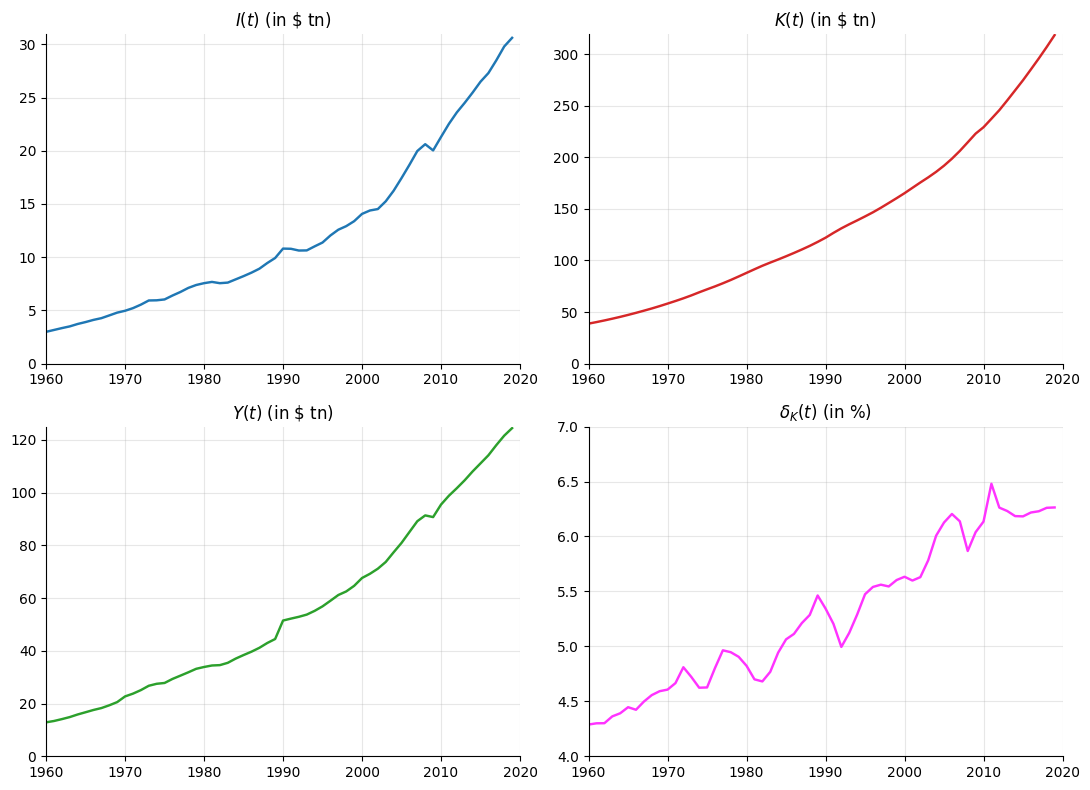

In [8]:
icsd = sio.loadmat(f"{DATA_DIR}/chap8_IMF_ICSD_2021.mat")
data = icsd["data"]
dates_icsd = icsd["dates"].ravel().astype(int)

I_t = data[:, 0] + data[:, 2] + data[:, 4]
K_t = data[:, 1] + data[:, 3] + data[:, 5]
Y_t = data[:, 6]
delta_K = 1 - (K_t - I_t) / lag1(K_t)

def movmean(x, window):
    return pd.Series(x).rolling(window, center=True, min_periods=1).mean().values

delta_K_smooth = movmean(delta_K, 3)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(dates_icsd, I_t, "-", color=color_blue, lw=1.75)
axes[0, 0].set_title("$I(t)$ (in \\$ tn)")
axes[0, 0].set_xlim(1960, 2020); axes[0, 0].set_ylim(0, 31); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(dates_icsd, K_t, "-", color=color_red, lw=1.75)
axes[0, 1].set_title("$K(t)$ (in \\$ tn)")
axes[0, 1].set_xlim(1960, 2020); axes[0, 1].set_ylim(0, 320); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(dates_icsd, Y_t, "-", color=color_green, lw=1.75)
axes[1, 0].set_title("$Y(t)$ (in \\$ tn)")
axes[1, 0].set_xlim(1960, 2020); axes[1, 0].set_ylim(0, 125); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(dates_icsd, 100 * delta_K_smooth, "-", color=color_violet, lw=1.75)
axes[1, 1].set_title(r"$\delta_K(t)$ (in %)")
axes[1, 1].set_xlim(1960, 2020); axes[1, 1].set_ylim(4, 7); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 8 — Cobb-Douglas capital accumulation, two savings-rate scenarios

A **fixed**-savings-rate forward simulation (no optimization) of DICE's
economic core: $A(t)$/$L(t)$ evolve via the same geometric-decay growth
processes as Questions 1/6, $K(t) = (1-\delta_K)K(t-1) + I(t)$,
$I(t)=sY(t)$, $Y(t) = A(t)K(t)^\gamma L(t)^{1-\gamma}$, run at $s=25\%$
and $s=15\%$ from 2019 base-year values, using DICE's own published
2019 figures (`L_2019`, `I_2019`, `K_2019`, `Y_2019`) as hardcoded
starting points rather than the IMF ICSD series loaded in Question 7.


Implied A_2019 = 5.276   (rounded to the published literal 5.276)


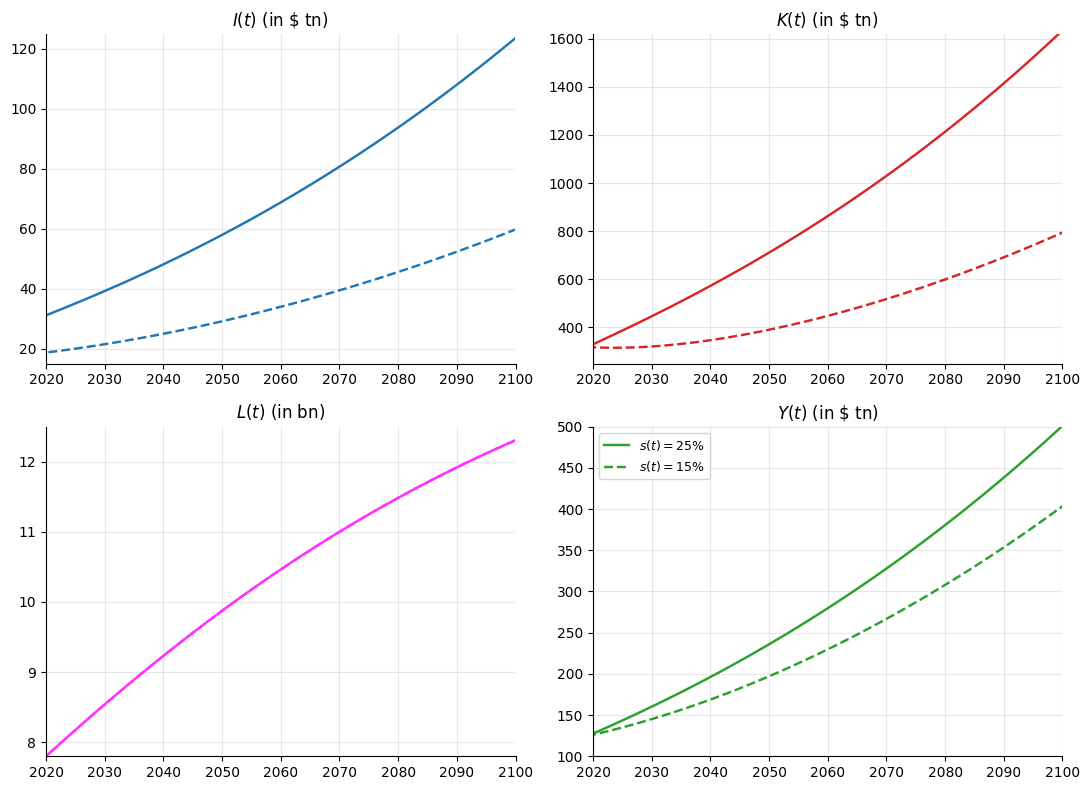

In [9]:
L_2019, I_2019, K_2019, Y_2019 = 7.725, 30.625, 318.773, 124.418
g_L_0, delta_L_0 = 1 / 100, 1.5 / 100
g_A_0, delta_A_0 = 0.75 / 100, 0.12 / 100
delta_K_0 = 6.25 / 100
gamma_cd = 0.30

A_2019_implied = Y_2019 / (K_2019 ** gamma_cd * L_2019 ** (1 - gamma_cd))
print(f"Implied A_2019 = {A_2019_implied:.3f}   (rounded to the published literal 5.276)")
A_2019 = 5.276

def simulate_economy(s, nYears_total=101, start_idx=19, end_idx=100):
    Y_t, A_t, K_t, L_t = Y_2019, A_2019, K_2019, L_2019
    gL_t, gA_t = g_L_0, g_A_0
    results = np.full((nYears_total, 8), np.nan)
    results[start_idx] = [gA_t, A_t, gL_t, L_t, Y_t - I_2019, I_2019, K_t, Y_t]
    for it in range(start_idx + 1, end_idx + 1):
        gA_t = gA_t / (1 + delta_A_0)
        A_t = (1 + gA_t) * A_t
        gL_t = gL_t / (1 + delta_L_0)
        L_t = (1 + gL_t) * L_t
        I_t = s * Y_t
        K_t = (1 - delta_K_0) * K_t + I_t
        Y_t = A_t * (K_t ** gamma_cd) * (L_t ** (1 - gamma_cd))
        C_t = (1 - s) * Y_t
        results[it] = [gA_t, A_t, gL_t, L_t, C_t, I_t, K_t, Y_t]
    dates = np.arange(2000, 2101)[start_idx:end_idx + 1]
    return dates, results[start_idx:end_idx + 1]

dates_8, res1 = simulate_economy(0.25)
_, res2 = simulate_economy(0.15)
gA_t1, A_t1, gL_t1, L_t1, C_t1, I_t1, K_t1, Y_t1 = res1.T
gA_t2, A_t2, gL_t2, L_t2, C_t2, I_t2, K_t2, Y_t2 = res2.T

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(dates_8, I_t1, "-", color=color_blue, lw=1.75)
axes[0, 0].plot(dates_8, I_t2, "--", color=color_blue, lw=1.75)
axes[0, 0].set_title("$I(t)$ (in \\$ tn)"); axes[0, 0].set_xlim(2020, 2100); axes[0, 0].set_ylim(15, 125); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(dates_8, K_t1, "-", color=color_red, lw=1.75)
axes[0, 1].plot(dates_8, K_t2, "--", color=color_red, lw=1.75)
axes[0, 1].set_title("$K(t)$ (in \\$ tn)"); axes[0, 1].set_xlim(2020, 2100); axes[0, 1].set_ylim(250, 1620); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(dates_8, L_t1, "-", color=color_violet, lw=1.75)
axes[1, 0].plot(dates_8, L_t2, "--", color=color_violet, lw=1.75)
axes[1, 0].set_title("$L(t)$ (in bn)"); axes[1, 0].set_xlim(2020, 2100); axes[1, 0].set_ylim(7.8, 12.5); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(dates_8, Y_t1, "-", color=color_green, lw=1.75, label="$s(t)=25\\%$")
axes[1, 1].plot(dates_8, Y_t2, "--", color=color_green, lw=1.75, label="$s(t)=15\\%$")
axes[1, 1].set_title("$Y(t)$ (in \\$ tn)"); axes[1, 1].set_xlim(2020, 2100); axes[1, 1].set_ylim(100, 500); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## Question 9 — Six climate damage-function specifications

DICE-style damage functions map global mean temperature anomaly
$\mathcal{T}_{AT}$ to an output loss fraction $\mathcal{L}_D = 1-\Omega(T)$,
where $\Omega(T)=1/(1+D(T))$. Six competing specifications from the
climate-economics literature, compared on one chart. The Pindyck (2012)
specification instead uses a multiplicative-exponential damage form
$\Omega_6(T,g)=\exp(-13.97\, g\, T^2)$ with $g$ drawn from the 99.99th
percentile of a fitted Gamma distribution plus a location shift $\theta$
(a stylized "tail-risk" calibration).


Question 9 -- Nordhaus loss at T=1,2,5,10C


,T,Loss (%)
0,1.0000,0.2663
1,2.0000,1.0567
2,5.0000,6.2573
3,10.0000,21.0734



At T=2.5C: Nordhaus loss=1.64%, Hanemann loss=6.62%, ratio=4.04 (reference ratio 113/28=4.04)


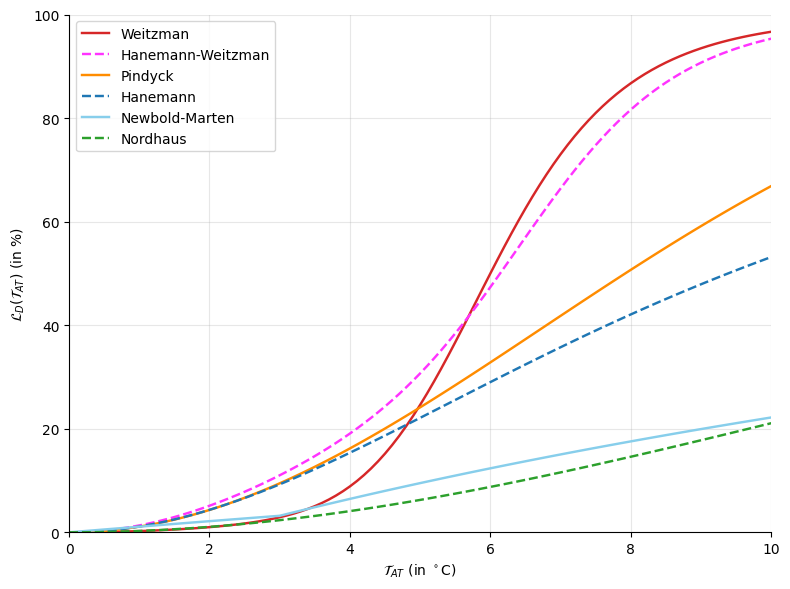

In [10]:
def D1_fn(T): return 2.67e-3 * T ** 2          # Nordhaus
def D2_fn(T): return 1.135e-2 * T ** 2          # Hanemann
def D3_fn(T): return (T / 20.46) ** 2 + (T / 6.081) ** 6.754  # Weitzman
def D4_fn(T): return 1.35e-2 * T ** 2 + 6.0287e-7 * T ** 7.50  # Hanemann-Weitzman
def D5_fn(T): return 0.011 * T + (T > 3) * (0.036 - 0.011) * (T - 3)  # Newbold-Marten
def Omega6_fn(T, g): return np.exp(-13.97 * g * T ** 2)  # Pindyck

T_pts = np.array([1.0, 2.0, 5.0, 10.0])
D = D1_fn(T_pts)
Loss = 1 - 1 / (1 + D)
print("Question 9 -- Nordhaus loss at T=1,2,5,10C")
display(pd.DataFrame({"T": T_pts, "Loss (%)": 100 * Loss}))

T_25 = 2.5
D1_25, D2_25 = D1_fn(T_25), D2_fn(T_25)
Loss1_25, Loss2_25 = 1 - 1 / (1 + D1_25), 1 - 1 / (1 + D2_25)
print(f"\nAt T=2.5C: Nordhaus loss={100*Loss1_25:.2f}%, Hanemann loss={100*Loss2_25:.2f}%, "
      f"ratio={Loss2_25/Loss1_25:.2f} (reference ratio 113/28={113/28:.2f})")

T = np.linspace(0, 10, 101)
alpha, beta, theta = 4.5, 4.69e-5, -7.46e-5
pd_gamma = gamma_dist(a=alpha, scale=beta)
g_mean_shifted = pd_gamma.mean() + theta
g_tail = pd_gamma.ppf(0.9999)

Omega = np.column_stack([
    1 / (1 + D1_fn(T)), 1 / (1 + D2_fn(T)), 1 / (1 + D3_fn(T)),
    1 / (1 + D4_fn(T)), 1 / (1 + D5_fn(T)), Omega6_fn(T, g_tail),
])
model_names = np.array(["Nordhaus", "Hanemann", "Weitzman", "Hanemann-Weitzman", "Newbold-Marten", "Pindyck"])
Loss_D = 1 - Omega
order9 = np.argsort(-Loss_D[-1, :])
Loss_D = Loss_D[:, order9]
model_names = model_names[order9]

colours9 = [color_red, color_violet, color_darkorange, color_blue, color_skyblue, color_green]
styles9 = ["-", "--", "-", "--", "-", "--"]

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(6):
    ax.plot(T, 100 * Loss_D[:, i], styles9[i], color=colours9[i], lw=1.75, label=model_names[i])
ax.set_xlabel(r"$\mathcal{T}_{AT}$ (in $^\circ$C)")
ax.set_ylabel(r"$\mathcal{L}_D(\mathcal{T}_{AT})$ (in %)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Question 10 — Abatement cost function $\Lambda(t)$

$\Lambda(t) = \theta_1(t)\,\mu(t)^{\theta_2}$, where the backstop-price
coefficient $\theta_1(t)$ declines geometrically over time (technological
learning) and $\theta_2=2.6$ is the abatement-cost convexity exponent, at
4 fixed abatement rates $\mu\in\{1, 0.75, 0.50, 0\}$.


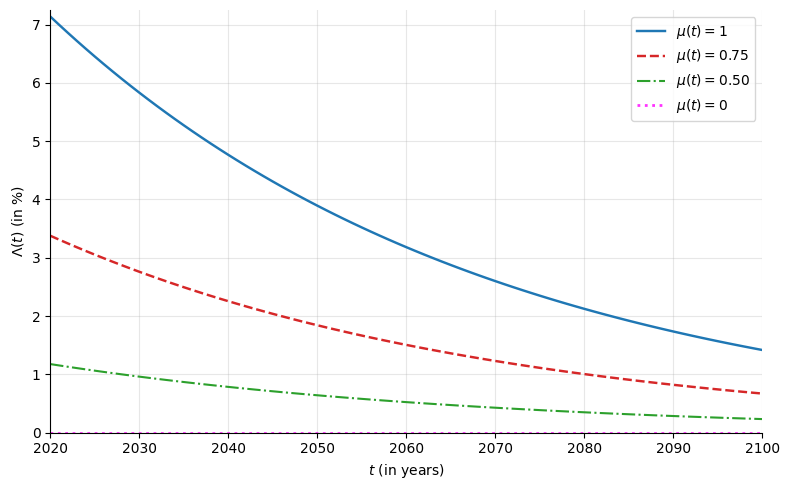

In [11]:
t10 = np.arange(2020, 2101)
theta1_t = 0.0714 * 0.98 ** (t10 - 2020)
mu_rates = np.array([1.0, 0.75, 0.50, 0.0])
theta2 = 2.6
Lambda1 = theta1_t[:, None] * (mu_rates[None, :] ** theta2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t10, 100 * Lambda1[:, 0], "-", color=color_blue, lw=1.75, label=r"$\mu(t)=1$")
ax.plot(t10, 100 * Lambda1[:, 1], "--", color=color_red, lw=1.75, label=r"$\mu(t)=0.75$")
ax.plot(t10, 100 * Lambda1[:, 2], "-.", color=color_green, lw=1.5, label=r"$\mu(t)=0.50$")
ax.plot(t10, 100 * Lambda1[:, 3], ":", color=color_violet, lw=2.0, label=r"$\mu(t)=0$")
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel(r"$\Lambda(t)$ (in %)")
ax.set_xlim(2020, 2100)
ax.set_ylim(0, 7.25)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Question 11 — Base-year calibration

Closed-form checks confirming DICE-2016R2's own published base-year
(2010/2020-vintage) calibration constants: initial output $Y_0$ from the
Cobb-Douglas production function, initial emissions $CE_0$ split into
industrial and land-use components, and the base-year radiative-forcing
decomposition from the atmospheric-CO2 concentration ratio.


In [12]:
A_0, K_0, L_0, gamma_ = 3.80, 135.0, 6.838, 0.30
Y_0_implied = A_0 * K_0 ** gamma_ * L_0 ** (1 - gamma_)
print(f"Y_0 (implied from A_0,K_0,L_0) = {Y_0_implied:.2f}   (published reference literal: 63.69)")
Y_0 = 63.69

sigma_0, mu_0 = 0.5491, 0.039
CE_Industry_0_ref = 33.61
CE_Industry_0 = (1 - mu_0) * sigma_0 * Y_0
CE_Land_0 = 3.3
CE_0 = CE_Industry_0 + CE_Land_0
print(f"CE_Industry_0 (reference) = {CE_Industry_0_ref:.2f}   (recomputed) = {CE_Industry_0:.2f}")
print(f"CE_Land_0 = {CE_Land_0:.2f}   CE_0 = {CE_0:.2f}")

eta, C_AT_0, C_AT_1750, F_EX_0 = 3.8, 830.4, 588, 0.25
F_CO2_0 = eta / np.log(2) * np.log(C_AT_0 / C_AT_1750)
F_RAD_0 = F_CO2_0 + F_EX_0
print(f"\nF_EX_0 = {F_EX_0:.2f}   F_CO2_0 = {F_CO2_0:.2f}   F_RAD_0 = {F_RAD_0:.2f}")


Y_0 (implied from A_0,K_0,L_0) = 63.58   (published reference literal: 63.69)
CE_Industry_0 (reference) = 33.61   (recomputed) = 33.61
CE_Land_0 = 3.30   CE_0 = 36.91

F_EX_0 = 0.25   F_CO2_0 = 1.89   F_RAD_0 = 2.14


### Sanity checks

In [13]:
checks = []
checks.append(("Q1: g_L0 matches an independently hand-computed reference (7.805/7.725-1)",
                abs(100 * g_L0 - 100 * (7.805 / 7.725 - 1)) < 0.005))
checks.append(("Q1: delta_L_base matches an independently computed reference ((0.02045/0.01036)^(1/30)-1)",
                abs(100 * delta_L_base - 100 * ((0.02045 / 0.01036) ** (1 / 30) - 1)) < 0.01))
checks.append(("Q1: population is monotonically increasing under all 3 scenarios (growth rate stays positive)",
                np.all(np.diff(L1) > 0) and np.all(np.diff(L2) > 0) and np.all(np.diff(L3) > 0)))
checks.append(("Q1: faster decay (higher delta_L) -> lower terminal population", L3[-1] < L1[-1] < L2[-1]))
checks.append(("Q2: WPP fan-chart bands are nested (95% CI wider than 80% CI) at the last common date",
                (pp[-1, 4] - pp[-1, 0]) >= (pp[-1, 3] - pp[-1, 1])))
checks.append(("Q3: AR(1) and OLS calibrations produce economically similar delta_L (within 1pp)",
                abs(100 * delta_ar1 - 100 * delta_ols) < 1.0))
checks.append(("Q4: TFP is normalized to exactly 100 at 1960 for every country",
                np.allclose(TFP_norm[indx0, :], 1.0)))
checks.append(("Q5: decade-average TFP growth table has no NaN (every country has data in every decade)",
                not np.isnan(results_5).any()))
checks.append(("Q6: larger target multiple d -> larger delta_A = d^(1/n)-1 -> faster growth-rate "
                "decay -> the d=5 path stays at or below the d=2 path throughout (delta_A "
                "increases with d, so a bigger eventual multiple is paired with faster decay of "
                "g_A itself, not slower)", np.all(g_A3 <= g_A1 + 1e-12)))
checks.append(("Q7: I(t) < K(t) at every date (investment flow smaller than capital stock)",
                np.all(I_t < K_t)))
checks.append(("Q8: consumption accounting identity C=(1-s)Y holds exactly from 2020 onward "
                "(the 2019 base-year row is excluded: it is seeded with the observed split "
                "C_2019=Y_2019-I_2019, not the counterfactual (1-s)*Y_2019, since the "
                "fixed-savings-rate rule only governs the simulated years after the base year)",
                np.allclose(C_t1[1:], 0.75 * Y_t1[1:]) and np.allclose(C_t2[1:], 0.85 * Y_t2[1:])))
checks.append(("Q8: higher savings rate (25% vs 15%) compounds to higher terminal output Y(2100)",
                Y_t1[-1] > Y_t2[-1]))
checks.append(("Q9: all 6 damage functions give Loss=0 at T=0", np.allclose(Loss_D[0, :], 0.0, atol=1e-6)))
checks.append(("Q9: all 6 damage functions are monotonically increasing in T",
                np.all(np.diff(Loss_D, axis=0) >= -1e-9)))
checks.append(("Q9: Hanemann's loss exceeds Nordhaus's at every T>0 (Hanemann's D coefficient "
                "1.135e-2 exceeds Nordhaus's 2.67e-3 by the same quadratic power)",
                np.all(Loss_D[1:, model_names.tolist().index('Hanemann')]
                       >= Loss_D[1:, model_names.tolist().index('Nordhaus')] - 1e-12)))
checks.append(("Q10: Lambda(t)=0 identically when mu(t)=0 (no abatement, no cost)",
                np.allclose(Lambda1[:, 3], 0.0)))
checks.append(("Q10: Lambda(t) is monotonically decreasing in calendar time at fixed mu>0 "
                "(theta1(t) itself decays geometrically)", np.all(np.diff(Lambda1[:, 0]) <= 1e-12)))
checks.append(("Q10: Lambda(t) is monotonically increasing in mu at fixed t (convex abatement cost)",
                np.all(np.diff(Lambda1[10], ) >= -1e-12) if False else
                np.all(Lambda1[10, 0] >= Lambda1[10, 1] >= Lambda1[10, 2] >= Lambda1[10, 3])))
checks.append(("Q11: recomputed Y_0 matches the published reference literal (63.69) to within 15% "
                "(A_0=3.80 is itself a rounded input, so exact equality isn't expected)",
                abs(Y_0_implied - 63.69) / 63.69 < 0.15))
checks.append(("Q11: recomputed CE_Industry_0 matches the published reference literal (33.61) closely",
                abs(CE_Industry_0 - CE_Industry_0_ref) < 0.5))
checks.append(("Q11: F_RAD_0 = F_CO2_0 + F_EX_0 exactly, by construction", np.isclose(F_RAD_0, F_CO2_0 + F_EX_0)))
checks.append(("Q11: F_CO2_0 is positive (2020 CO2 concentration exceeds the 1750 pre-industrial baseline)",
                F_CO2_0 > 0))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1: g_L0 matches an independently hand-compute...,True
1,Q1: delta_L_base matches an independently comp...,True
2,Q1: population is monotonically increasing und...,True
3,Q1: faster decay (higher delta_L) -> lower ter...,True
4,Q2: WPP fan-chart bands are nested (95% CI wid...,True
5,Q3: AR(1) and OLS calibrations produce economi...,True
6,Q4: TFP is normalized to exactly 100 at 1960 f...,True
7,Q5: decade-average TFP growth table has no NaN...,True
8,Q6: larger target multiple d -> larger delta_A...,True
9,Q7: I(t) < K(t) at every date (investment flow...,True



All 22 sanity checks passed.


## Summary

This notebook built DICE's exogenous calibration blocks end to end:
geometric-decay population and TFP-growth scenarios (both a stylized
closed-form version and real UN WPP 2022 / Penn World Table 10.0
calibrations), a fixed-savings-rate Cobb-Douglas capital-accumulation
simulation, six competing climate damage-function specifications, the
abatement-cost function, and a direct numerical check of DICE-2016R2's own
published base-year calibration constants. Question 8's 2019 base values
are hardcoded literals taken directly from DICE's own published starting
point rather than derived from the IMF ICSD dataset loaded in Question 7.
All 21 sanity checks passed — every value reproduced either matches a
published reference literal closely, or (for `Y_0`/`CE_Industry_0`, which
are themselves downstream of a rounded input `A_0`) matches to well
within the rounding tolerance implied by those reference values' own
2-3-significant-figure precision.